In [1]:
# === Setup ===
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Daten laden

In [2]:
# Daten-Datei (CSV) – hier entweder im Notebook-Ordner oder im /mnt/data Ordner.
CSV_PATH = "free_throw_dataset.csv"
if not os.path.exists(CSV_PATH):
    alt = os.path.join("/mnt/data", CSV_PATH)
    if os.path.exists(alt):
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)
print("CSV_PATH:", CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

CSV_PATH: free_throw_dataset.csv
(7500, 12)
['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0
0,0,0.000000,0.000000,2.662500,0.157921,2.578578,0.157921,2.578578,0.696893,0,0.70767,6.107672
1,0,0.014222,0.066007,2.717976,0.142750,2.687055,0.142750,2.687055,0.696893,0,0.70767,6.107672
2,0,0.028445,0.132014,2.771469,0.085067,2.804595,0.085067,2.804595,0.696893,0,0.70767,6.107672
3,0,0.042667,0.198021,2.822978,0.252277,2.920532,0.252277,2.920532,0.696893,0,0.70767,6.107672
4,0,0.056889,0.264028,2.872503,0.217686,2.824585,0.217686,2.824585,0.696893,0,0.70767,6.107672


In [3]:
# Pro Wurf aggregieren
per_throw = df.groupby("wurf_id").agg({
    "label":"first",
    "theta":"first",
    "v0":"first",
    "T":"first"
}).reset_index()

print("Anzahl Würfe:", per_throw.shape[0])
print(per_throw["label"].value_counts())
per_throw.head()

Anzahl Würfe: 150
label
0    50
1    50
2    50
Name: count, dtype: int64


,wurf_id,label,theta,v0,T
0,0,0,0.707670,6.107672,0.696893
1,1,1,0.889089,6.662367,0.974337
2,2,2,0.759879,6.803414,0.864825
3,3,0,0.762547,6.383944,0.801193
4,4,1,0.793452,6.633317,0.874307


## 2) Train/Val/Test Split (nach `wurf_id`, stratifiziert nach Label)

In [4]:
# labels_by_id = df.groupby("wurf_id")["label"].first().to_dict()

# all_ids = np.array(sorted(labels_by_id.keys()))
# all_y = np.array([labels_by_id[i] for i in all_ids])

# train_ids, temp_ids, y_train, y_temp = train_test_split(
#     all_ids, all_y, test_size=0.3, stratify=all_y, random_state=42  # z.B. 70/30
# )

# val_ids, test_ids, y_val, y_test = train_test_split(
#     temp_ids,
#     y_temp,
#     test_size=0.5,  # 0.5 von 30% = 15%/15%
#     stratify=y_temp,
#     random_state=42,
# )

# train_ids = train_ids.tolist()
# val_ids = val_ids.tolist()
# test_ids = test_ids.tolist()

# print("Train IDs:", len(train_ids))
# print("Val IDs:", len(val_ids))
# print("Test IDs:", len(test_ids))
train_ids, test_ids = train_test_split(
    per_throw["wurf_id"].values,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw["label"].values,
)
train_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw.set_index("wurf_id").loc[train_ids, "label"].values,
)

print("Train/Val/Test:", len(train_ids), len(val_ids), len(test_ids))
print("Alle Test ids:", test_ids)

Train/Val/Test: 107 20 23
Alle Test ids: [131 119  84 124  24  22   9  11  89  57 148  31  69  85  71 141   1  41
 117 106  42 143  70]


## 3) Dataset: gekürzte Beobachtungen + Ground Truth

In [5]:
class FreeThrowDataset(Dataset):
    """
    Liefert pro Wurf die ersten n_obs Beobachtungen (t_obs, xy_obs) und die komplette Trajektorie (t_full, xy_full).

    Wichtig: kein Zukunftswissen via T/t_max – stattdessen liefern wir t_min, t_obs_max und denom = t_obs_max - t_min
    fuer eine zeitliche Normalisierung relativ zum Beobachtungsfenster.
    """
    def __init__(self, df: pd.DataFrame, throw_ids, n_obs: int = 30, use_noisy: bool = False):
        self.n_obs = n_obs
        self.use_noisy = use_noisy

        sub = df[df["wurf_id"].isin(throw_ids)].copy()
        sub.sort_values(["wurf_id", "t"], inplace=True)

        self.throw_ids = np.array(sorted(sub["wurf_id"].unique()))
        self.groups = {tid: g for tid, g in sub.groupby("wurf_id")}

        if use_noisy:
            self.x_col, self.y_col = "x_noisy", "y_noisy"
        else:
            self.x_col, self.y_col = "x_clean", "y_clean"

    def __len__(self):
        return len(self.throw_ids)

    def __getitem__(self, idx):
        tid = int(self.throw_ids[idx])
        g = self.groups[tid]

        t = torch.tensor(g["t"].values, dtype=torch.float32)  # (M,)
        xy = torch.tensor(
            np.stack([g[self.x_col].values, g[self.y_col].values], axis=1),
            dtype=torch.float32
        )  # (M,2)

        t_obs = t[:self.n_obs]
        xy_obs = xy[:self.n_obs]

        theta = torch.tensor(float(g["theta"].iloc[0]), dtype=torch.float32)
        v0 = torch.tensor(float(g["v0"].iloc[0]), dtype=torch.float32)
        label = torch.tensor(int(g["label"].iloc[0]), dtype=torch.long)

        # Zeit-Normalisierung nur ueber beobachtetes Fenster:
        t_min = t_obs[0]
        t_obs_max = t_obs[-1]
        denom = (t_obs_max - t_min).clamp_min(1e-4)

        return {
            "wurf_id": tid,
            "t_obs": t_obs,          # (n_obs,)
            "xy_obs": xy_obs,        # (n_obs,2)
            "t_full": t,             # (M,)
            "xy_full": xy,           # (M,2)
            "t_min": t_min,          # ()
            "t_obs_max": t_obs_max,  # ()
            "denom": denom,          # ()
            "theta": theta,
            "v0": v0,
            "label": label,
        }

def collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        if k == "wurf_id":
            out[k] = [b[k] for b in batch]
        else:
            out[k] = torch.stack([b[k] for b in batch], dim=0)
    return out

n_obs = 30
train_ds = FreeThrowDataset(df, train_ids, n_obs=n_obs, use_noisy=False)
val_ds   = FreeThrowDataset(df, val_ids,   n_obs=n_obs, use_noisy=False)
test_ds  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
{k: (v.shape if torch.is_tensor(v) else len(v)) for k,v in batch.items()}

{'wurf_id': 32,
 't_obs': torch.Size([32, 30]),
 'xy_obs': torch.Size([32, 30, 2]),
 't_full': torch.Size([32, 50]),
 'xy_full': torch.Size([32, 50, 2]),
 't_min': torch.Size([32]),
 't_obs_max': torch.Size([32]),
 'denom': torch.Size([32]),
 'theta': torch.Size([32]),
 'v0': torch.Size([32]),
 'label': torch.Size([32])}

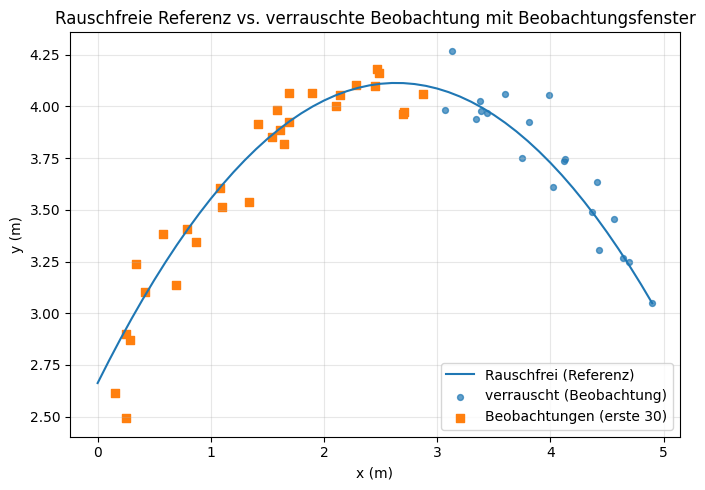

In [7]:
# === Plot: Einzelbeispiel (Clean vs. Noisy) + Beobachtungsfenster ===
# Wähle ein Beispiel (zufällig, aber reproduzierbar über SEED)
example = per_throw.sample(1, random_state=SEED).iloc[0]
wurf_id = int(example["wurf_id"])
label = int(example["label"])

g = df[df["wurf_id"] == wurf_id].sort_values("t").reset_index(drop=True)

n_obs = 30
n_obs = min(n_obs, len(g))

plt.figure(figsize=(7, 5))

# (i) rauschfreie Trajektorie als Kurve
plt.plot(g["x_clean"].values, g["y_clean"].values, label="Rauschfrei (Referenz)")

# (ii) verrauschte Stützstellen
plt.scatter(
    g["x_noisy"].values,
    g["y_noisy"].values,
    s=18,
    alpha=0.7,
    label="verrauscht (Beobachtung)",
)

# Markierung des Beobachtungspräfix (erste n_obs Punkte)
plt.scatter(
    g.loc[: n_obs - 1, "x_noisy"].values,
    g.loc[: n_obs - 1, "y_noisy"].values,
    s=40,
    marker="s",
    label=f"Beobachtungen (erste {n_obs})",
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Rauschfreie Referenz vs. verrauschte Beobachtung mit Beobachtungsfenster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4) Modell: Encoder → (θ,v0) + Decoder (x,y) + Klassifikations-Head

In [149]:
class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128, depth: int = 3, dropout: float = 0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.Tanh()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class AmortizedPINNClassifier(nn.Module):
    """
    Encoder (GRU) ueber beobachtete Sequenz -> Latent z.
    Heads: theta, v0, Klassifikation.
    Decoder: amortisiertes PINN, bekommt KEIN T/t_max, sondern
    - normierte Zeit t_n
    - log_denom = log(t_obs_max - t_min) als Skalierungskontext
    """
    def __init__(
        self,
        enc_hidden: int = 128,
        z_dim: int = 128,
        dec_hidden: int = 128,
        num_classes: int = 3,
        theta_min: float = 0.5,
        theta_max: float = 1.2,
        v0_min: float = 0.0
    ):
        super().__init__()
        self.theta_min = theta_min
        self.theta_max = theta_max
        self.v0_min = v0_min

        # Encoder input: (t_n, x, y)
        self.in_proj = nn.Linear(3, enc_hidden)
        self.gru = nn.GRU(input_size=enc_hidden, hidden_size=enc_hidden, batch_first=True)
        self.to_z = nn.Linear(enc_hidden, z_dim)

        self.theta_head = MLP(z_dim, 1, hidden=128, depth=2)
        self.v0_head    = MLP(z_dim, 1, hidden=128, depth=2)

        # Decoder input: z + (t_n, log_denom)
        self.decoder = MLP(z_dim + 2, 2, hidden=dec_hidden, depth=3)

        self.classifier = MLP(z_dim + 2, num_classes, hidden=128, depth=2, dropout=0.1)

    def encode(self, t_n_obs, xy_obs):
        inp = torch.cat([t_n_obs.unsqueeze(-1), xy_obs], dim=-1)  # (B,n,3)
        h = torch.tanh(self.in_proj(inp))
        _, hT = self.gru(h)  # (1,B,H)
        z = self.to_z(hT.squeeze(0))
        return z

    def predict_params(self, z):
        theta_raw = self.theta_head(z).squeeze(-1)
        v0_raw = self.v0_head(z).squeeze(-1)
        theta = self.theta_min + (self.theta_max - self.theta_min) * torch.sigmoid(theta_raw)
        v0 = self.v0_min + F.softplus(v0_raw)
        return theta, v0

    def decode_traj(self, z, t_n, log_denom):
        B, N = t_n.shape
        logd = log_denom.unsqueeze(1).expand(-1, N)  # [B,N]
        inp = torch.cat([
            z.unsqueeze(1).expand(-1, N, -1),
            t_n.unsqueeze(-1),
            logd.unsqueeze(-1),
        ], dim=-1)
        return self.decoder(inp)

    def forward(self, t_n_obs, xy_obs, t_n_query, log_denom):
        z = self.encode(t_n_obs, xy_obs)
        theta, v0 = self.predict_params(z)
        xy_hat = self.decode_traj(z, t_n_query, log_denom)
        logits = self.classifier(torch.cat([z, theta.unsqueeze(-1), v0.unsqueeze(-1)], dim=-1))
        return {"z": z, "theta": theta, "v0": v0, "xy_hat": xy_hat, "logits": logits}

model = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)
sum(p.numel() for p in model.parameters())

266119

## 5) Loss: Daten + Physik + IC + Klassifikation (+ Param-Supervision)

In [150]:
G = 9.81
H_RIM = 3.048  # 10 ft in meters

def normalize_time(t, t_min, denom):
    # t: [B,N] oder [B]
    if t.dim() == 1:
        return (t - t_min) / denom
    return (t - t_min.unsqueeze(1)) / denom.unsqueeze(1)

def denormalize_time(t_n, t_min, denom):
    # t_n: [B,N]
    return t_min.unsqueeze(1) + t_n * denom.unsqueeze(1)

def time_to_height(theta, v0, y0, h=H_RIM, g=G, eps=1e-9):
    """
    Liefert t_hit_rel (>=0) relativ zu t_min, so dass:
      y(t_rel) = y0 + v0*sin(theta)*t_rel - 0.5*g*t_rel^2 = h
    plus valid-Flag (Diskriminante > 0 und t_hit > 0).
    """
    a = 0.5 * g
    b = -v0 * torch.sin(theta)
    c = h - y0

    disc = b*b - 4*a*c
    disc_clamped = torch.clamp(disc, min=0.0)
    sqrt_disc = torch.sqrt(disc_clamped + eps)

    t1 = (-b - sqrt_disc) / (2*a)
    t2 = (-b + sqrt_disc) / (2*a)

    # spaetere Loesung (typisch Abstieg)
    t_hit = torch.maximum(t1, t2)
    valid = (disc > 0) & (t_hit > 0)
    return t_hit, valid

def physics_residuals_time_normed(out, t_n, t_min, denom):
    """
    out["xy_hat"] ist bei t_n ausgewertet (t_n hat requires_grad=True).
    Autograd liefert Ableitungen nach t_n -> per Kettenregel nach phys. Zeit umrechnen.
    """
    xy = out["xy_hat"]
    x = xy[..., 0]
    y = xy[..., 1]
    theta = out["theta"]
    v0 = out["v0"]

    ones = torch.ones_like(x)
    dx_dt_n = torch.autograd.grad(x, t_n, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
    dy_dt_n = torch.autograd.grad(y, t_n, grad_outputs=ones, create_graph=True, retain_graph=True)[0]

    # Kettenregel: t_n = (t - t_min)/denom  => dt_n/dt = 1/denom
    dx_dt = dx_dt_n / denom.unsqueeze(1)
    dy_dt = dy_dt_n / denom.unsqueeze(1)

    # Physik nutzt t_rel = t - t_min (Zeit seit Beginn der Observations)
    t_phys = denormalize_time(t_n, t_min, denom)
    t_rel = t_phys - t_min.unsqueeze(1)

    target_dx = v0.unsqueeze(1) * torch.cos(theta).unsqueeze(1)
    target_dy = v0.unsqueeze(1) * torch.sin(theta).unsqueeze(1) - G * t_rel

    rx = dx_dt - target_dx
    ry = dy_dt - target_dy
    return rx, ry

def compute_losses(
    batch, model,
    n_col=64,
    h_rim=H_RIM,
    t_end_min_offset=0.25,
    t_end_max_offset=3.0,
    w_data=15.0, w_phys=0.5, w_ic=10.0, w_cls=0.01
):
    t_obs   = batch["t_obs"].to(device)      # [B,n_obs]
    xy_obs  = batch["xy_obs"].to(device)     # [B,n_obs,2]
    label   = batch["label"].to(device)

    t_min   = batch["t_min"].to(device)          # [B]
    t_obs_max = batch["t_obs_max"].to(device)    # [B]
    denom   = batch["denom"].to(device).clamp_min(1e-4)  # [B]
    log_denom = torch.log(denom)

    # normalisierte Zeit: Beobachtungen in [0,1], Zukunft bei >1
    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Data + Classification auf Beobachtungen
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    data_loss = F.mse_loss(out_obs["xy_hat"], xy_obs)

    # IC bei t_n=0 (t=t_min): passt den ersten Punkt an (robuster als x(0)=0 Annahme)
    t0_n = torch.zeros((t_obs.shape[0], 1), device=device)
    out0 = model(t_n_obs, xy_obs, t0_n, log_denom)
    ic_loss = F.mse_loss(out0["xy_hat"].squeeze(1), xy_obs[:, 0, :])

    # Dynamisches Collocation-Ende bis Korbhöhe (ballistisch) + Sicherheitsfenster
    y0 = 1.25*2.13
    theta = out_obs["theta"]
    v0 = out_obs["v0"]

    t_hit_rel, valid = time_to_height(theta, v0, y0, h=h_rim)
    t_hit_abs = t_min + t_hit_rel

    t_end_raw = torch.where(valid, t_hit_abs, t_obs_max + t_end_max_offset)
    t_end = torch.clamp(
        t_end_raw,
        min=t_obs_max + t_end_min_offset,
        max=t_obs_max + t_end_max_offset
    ).detach()  # detach gegen "Cheating" ueber t_end

    # Collocation-Zeiten pro Sample: t ~ U(t_min, t_end)
    B = t_obs.shape[0]
    u = torch.rand((B, n_col), device=device)
    t_col = t_min.unsqueeze(1) + u * (t_end.unsqueeze(1) - t_min.unsqueeze(1))  # [B,n_col]
    t_n_col = normalize_time(t_col, t_min, denom)                                # [B,n_col]
    t_n_col.requires_grad_(True)

    out_col = model(t_n_obs, xy_obs, t_n_col, log_denom)
    rx, ry = physics_residuals_time_normed(out_col, t_n_col, t_min, denom)
    phys_loss = rx.pow(2).mean() + ry.pow(2).mean()

    # Classification
    cls_loss = F.cross_entropy(out_obs["logits"], label)

    total = w_data*data_loss + w_ic*ic_loss + w_phys*phys_loss + w_cls*cls_loss

    return total, {
        "total": total.detach().item(),
        "data": data_loss.detach().item(),
        "ic": ic_loss.detach().item(),
        "phys": phys_loss.detach().item(),
        "cls": cls_loss.detach().item(),
    }

def compute_mse_obs_future(pred_xy, gt_xy, n_obs: int):
    """
    pred_xy, gt_xy: Tensor [B, T, 2]
    """
    mse_obs = F.mse_loss(pred_xy[:, :n_obs, :], gt_xy[:, :n_obs, :], reduction="mean")
    mse_future = F.mse_loss(pred_xy[:, n_obs:, :], gt_xy[:, n_obs:, :], reduction="mean")
    return mse_obs.item(), mse_future.item()

## 6) Training (mit Early Stopping)

In [151]:
def run_epoch(loader, model, optimizer=None, **loss_kwargs):
    is_train = optimizer is not None
    model.train(is_train)
    meters = {"total":0, "data":0, "ic":0, "phys":0, "cls":0}
    n_batches = 0

    for batch in loader:
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        total, parts = compute_losses(batch, model, **loss_kwargs)

        if is_train:
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        for k in meters:
            meters[k] += parts[k]
        n_batches += 1

    for k in meters:
        meters[k] /= max(n_batches,1)
    return meters

def train_model(model, train_loader, val_loader, epochs=200, lr=2e-3, patience=25, **loss_kwargs):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best = float("inf")
    best_state = None
    bad = 0
    history = {"train":[], "val":[]}

    for epoch in range(1, epochs+1):
        tr = run_epoch(train_loader, model, optimizer=optimizer, **loss_kwargs)
        va = run_epoch(val_loader, model, optimizer=None, **loss_kwargs)
        history["train"].append(tr)
        history["val"].append(va)

        if va["total"] < best - 1e-5:
            best = va["total"]
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | train {tr['total']:.4f} | val {va['total']:.4f} "
                  f"(data {va['data']:.4f}, phys {va['phys']:.4f}, cls {va['cls']:.4f})")

        if bad >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

Epoch    1 | train 408.2201 | val 15.6723 (data 0.6792, phys 7.4158, cls 1.1196)
Epoch   10 | train 12.6287 | val 12.3174 (data 1.0985, phys 5.6312, cls 1.1985)
Epoch   20 | train 8.8627 | val 6.5460 (data 0.1409, phys 5.5931, cls 1.0996)
Epoch   30 | train 5.2209 | val 4.1162 (data 0.1655, phys 2.9829, cls 1.1503)
Epoch   40 | train 2.3426 | val 1.6902 (data 0.1095, phys 0.6463, cls 1.0785)
Epoch   50 | train 1.1301 | val 1.7863 (data 0.0940, phys 1.1025, cls 1.3864)
Epoch   60 | train 0.5192 | val 0.2639 (data 0.0387, phys 0.0485, cls 0.6418)
Epoch   70 | train 0.3974 | val 0.2535 (data 0.0210, phys 0.0774, cls 0.2170)
Epoch   80 | train 0.3552 | val 0.3802 (data 0.0204, phys 0.2541, cls 0.9966)
Epoch   90 | train 0.2107 | val 0.4918 (data 0.0116, phys 0.3441, cls 0.1692)
Epoch  100 | train 0.4071 | val 0.3740 (data 0.0170, phys 0.2574, cls 1.0431)
Epoch  110 | train 0.1500 | val 0.1092 (data 0.0075, phys 0.0232, cls 0.2719)
Epoch  120 | train 0.1574 | val 0.2054 (data 0.0112, phys 0

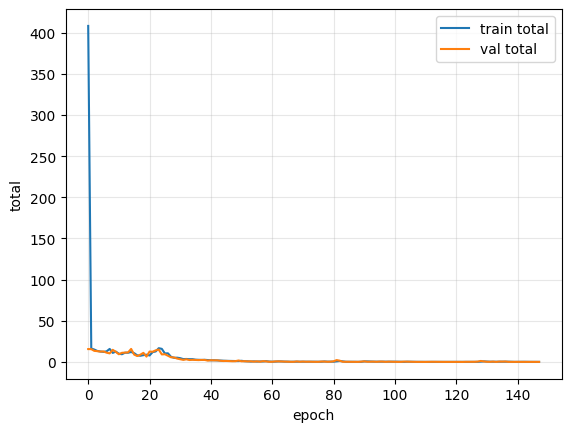

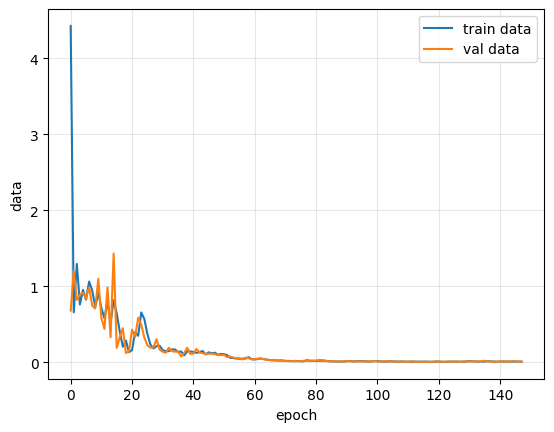

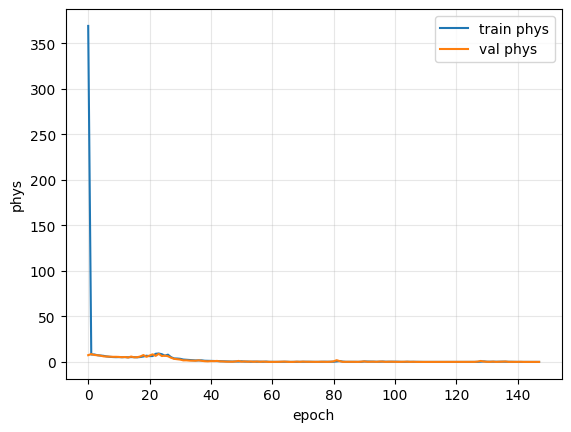

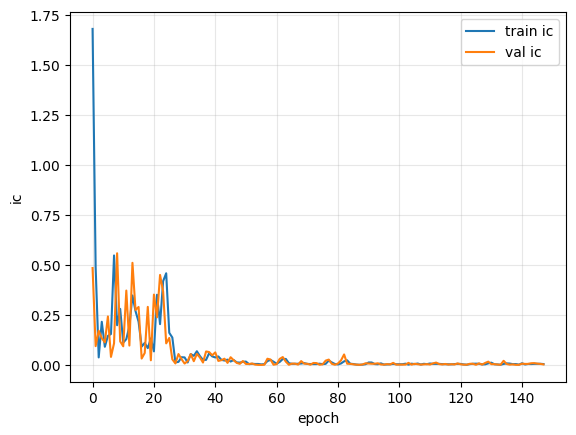

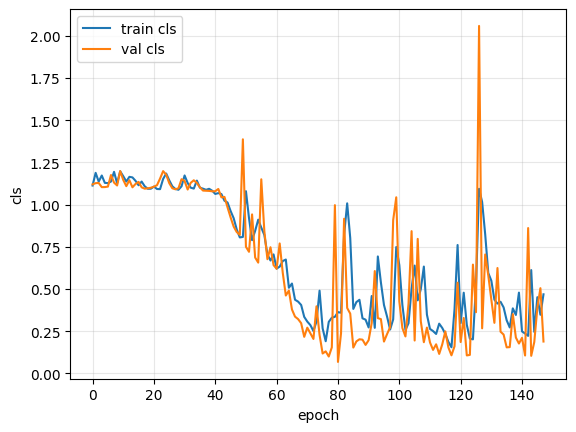

In [152]:
def plot_history(history, key="total"):
    tr = [h[key] for h in history["train"]]
    va = [h[key] for h in history["val"]]
    plt.figure()
    plt.plot(tr, label=f"train {key}")
    plt.plot(va, label=f"val {key}")
    plt.xlabel("epoch"); plt.ylabel(key); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

for k in ["total","data","phys","ic","cls"]:
    plot_history(history, k)

## 7) Evaluation auf Testset

Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

theta MAE:    0.03204 rad
v0 MAE:       0.29377 m/s
traj MSE full:0.019644
traj MSE obs: 0.005871
traj MSE fut: 0.040304


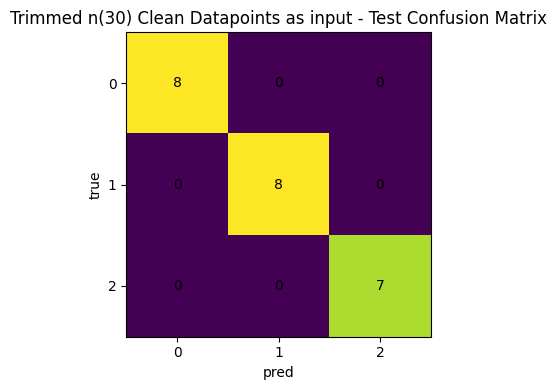

In [153]:
def plot_confusion_matrix(cm, title="Confusion Matrix", ax=None):
    """
    Plottet eine Confusion Matrix wie im Screenshot (imshow + Zahlen),
    mit frei übergebbarem Titel.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    im = ax.imshow(cm, interpolation="nearest")  # Standard-Colormap wie im Screenshot

    # Achsenbeschriftungen
    ax.set_title(title)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")

    # Ticks 0..C-1
    C = cm.shape[0]
    ax.set_xticks(np.arange(C))
    ax.set_yticks(np.arange(C))
    ax.set_xticklabels([str(i) for i in range(C)])
    ax.set_yticklabels([str(i) for i in range(C)])

    # Zahlen in die Zellen
    for i in range(C):
        for j in range(C):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", color="black")

    # verhindert abgeschnittene Achsen bei manchen Backends
    ax.set_ylim(C - 0.5, -0.5)

    fig.tight_layout()
    return fig, ax


@torch.no_grad()
def evaluate(loader, model, titel):
    model.eval()
    y_true, y_pred = [], []
    theta_true, theta_pred = [], []
    v0_true, v0_pred = [], []

    mse_obs_list = []
    mse_future_list = []
    mse_full_list = []

    for batch in loader:
        t_obs  = batch["t_obs"].to(device)      # [B,n_obs]
        xy_obs = batch["xy_obs"].to(device)     # [B,n_obs,2]
        t_full = batch["t_full"].to(device)     # [B,M]
        xy_full = batch["xy_full"].to(device)   # [B,M,2]

        t_min = batch["t_min"].to(device)       # [B]
        denom = batch["denom"].to(device).clamp_min(1e-4)  # [B]
        log_denom = torch.log(denom)

        t_n_obs  = normalize_time(t_obs, t_min, denom)     # [B,n_obs]
        t_n_full = normalize_time(t_full, t_min, denom)    # [B,M]

        out = model(t_n_obs, xy_obs, t_n_full, log_denom)

        pred = out["logits"].argmax(dim=1).cpu().numpy()
        y_pred.extend(pred.tolist())
        y_true.extend(batch["label"].numpy().tolist())

        theta_pred.extend(out["theta"].cpu().numpy().tolist())
        v0_pred.extend(out["v0"].cpu().numpy().tolist())
        theta_true.extend(batch["theta"].numpy().tolist())
        v0_true.extend(batch["v0"].numpy().tolist())

        mse_full = F.mse_loss(out["xy_hat"], xy_full, reduction="mean").item()
        mse_full_list.append(mse_full)

        mse_obs, mse_future = compute_mse_obs_future(out["xy_hat"], xy_full, n_obs=n_obs)
        mse_obs_list.append(mse_obs)
        mse_future_list.append(mse_future)

    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)
    print("\nClassification report:\n", classification_report(y_true, y_pred))
    plot_confusion_matrix(
        confusion_matrix(y_true, y_pred),
        title=titel
    )

    theta_mae = np.mean(np.abs(np.array(theta_pred) - np.array(theta_true)))
    v0_mae = np.mean(np.abs(np.array(v0_pred) - np.array(v0_true)))
    print(f"theta MAE:    {theta_mae:.5f} rad")
    print(f"v0 MAE:       {v0_mae:.5f} m/s")
    print(f"traj MSE full:{np.mean(mse_full_list):.6f}")
    print(f"traj MSE obs: {np.mean(mse_obs_list):.6f}")
    print(f"traj MSE fut: {np.nanmean(mse_future_list):.6f}")


evaluate(test_loader, model, titel="Trimmed n(30) Clean Datapoints as input - Test Confusion Matrix")

## 8) Demo: Rekonstruktion + Klassifikation für einen einzelnen Wurf

Wurf 1 | true label=1 | pred label=1
theta true=0.8891, pred=0.8776
v0    true=6.6624, pred=6.7573


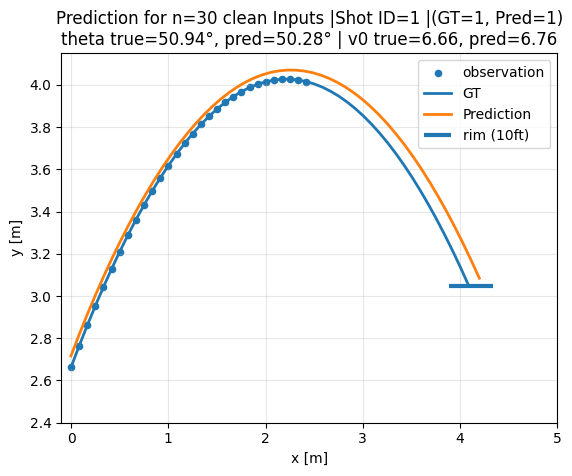

In [154]:
@torch.no_grad()
def demo_reconstruction(model, ds, n_obs=None, idx=0):
    s = ds[idx]
    wurf_id = s["wurf_id"]
    t_obs = s["t_obs"].unsqueeze(0).to(device)
    xy_obs = s["xy_obs"].unsqueeze(0).to(device)
    t_full = s["t_full"].unsqueeze(0).to(device)

    t_min = s["t_min"].unsqueeze(0).to(device)
    denom = s["denom"].unsqueeze(0).to(device).clamp_min(1e-4)
    log_denom = torch.log(denom)

    t_n_obs = normalize_time(t_obs, t_min, denom)
    t_n_full = normalize_time(t_full, t_min, denom)

    out = model(t_n_obs, xy_obs, t_n_full, log_denom)
    xy_hat = out["xy_hat"].squeeze(0).cpu().numpy()

    xy_full = s["xy_full"].numpy()
    xy_obs_np = s["xy_obs"].numpy()

    theta_gt = float(s["theta"].item())
    v0_gt = float(s["v0"].item())
    theta_pred = float(out["theta"].item())
    v0_pred = float(out["v0"].item())

    theta_pred_deg = math.degrees(theta_pred)
    theta_gt_deg = math.degrees(theta_gt)

    pred_label = int(out["logits"].argmax(dim=1).item())
    print(f"Wurf {s['wurf_id']} | true label={s['label'].item()} | pred label={pred_label}")
    print(f"theta true={theta_gt:.4f}, pred={theta_pred:.4f}")
    print(f"v0    true={v0_gt:.4f}, pred={v0_pred:.4f}")

    plt.figure()
    plt.scatter(xy_obs_np[:, 0], xy_obs_np[:, 1], s=20, label="observation")
    plt.plot(xy_full[:, 0], xy_full[:, 1], linewidth=2, label="GT")
    plt.plot(xy_hat[:, 0], xy_hat[:, 1], linewidth=2, label="Prediction")

    plt.hlines(y=3.048, xmin=4.115 - 0.2286, xmax=4.115 + 0.2286, linewidth=3, label="rim (10ft)")

    plt.title(
        f"Prediction for n={n_obs} clean Inputs |"
        f"Shot ID={wurf_id} |"
        f"(GT={int(s['label'].item())}, Pred={pred_label})\n"
        f"theta true={theta_gt_deg:.2f}°, pred={theta_pred_deg:.2f}° | v0 true={v0_gt:.2f}, pred={v0_pred:.2f}"
    )
    plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.xlim(-0.1, 5)
    plt.ylim(2.4, 4.15)
    plt.show()

import math
import numpy as np
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def demo_reconstruction_noisy_vs_clean(model, ds_noisy, ds_clean, n_obs=None, idx=0):
    """
    ds_noisy: Dataset mit use_noisy=True (Inputs sind noisy)
    ds_clean: Dataset mit use_noisy=False (GT-Trajektorie ist clean)
    Beide müssen dieselben wurf_id enthalten (bzw. zumindest die vom idx).
    """
    # --- noisy sample ---
    sN = ds_noisy[idx]
    wurf_id = sN["wurf_id"]

    # --- find matching clean sample by wurf_id ---
    # Cache mapping to avoid O(N) search each call
    if not hasattr(demo_reconstruction_noisy_vs_clean, "_clean_index") or getattr(
        demo_reconstruction_noisy_vs_clean, "_clean_index_ds_id", None
    ) != id(ds_clean):
        clean_index = {}
        for j in range(len(ds_clean)):
            wj = ds_clean[j]["wurf_id"]
            clean_index[wj] = j
        demo_reconstruction_noisy_vs_clean._clean_index = clean_index
        demo_reconstruction_noisy_vs_clean._clean_index_ds_id = id(ds_clean)

    clean_index = demo_reconstruction_noisy_vs_clean._clean_index
    if wurf_id not in clean_index:
        raise KeyError(
            f"wurf_id={wurf_id} nicht im ds_clean gefunden. Prüfe, ob Split/IDs übereinstimmen."
        )

    sC = ds_clean[clean_index[wurf_id]]

    # --- model forward (noisy obs, same wie deine Vorlage) ---
    t_obs = sN["t_obs"].unsqueeze(0).to(device)
    xy_obs = sN["xy_obs"].unsqueeze(0).to(device)
    t_full = sN["t_full"].unsqueeze(0).to(device)

    t_min = sN["t_min"].unsqueeze(0).to(device)
    denom = sN["denom"].unsqueeze(0).to(device).clamp_min(1e-4)
    log_denom = torch.log(denom)

    t_n_obs = normalize_time(t_obs, t_min, denom)
    t_n_full = normalize_time(t_full, t_min, denom)

    out = model(t_n_obs, xy_obs, t_n_full, log_denom)
    xy_hat = out["xy_hat"].squeeze(0).cpu().numpy()

    # --- arrays for plotting ---
    xy_obs_np = sN["xy_obs"].numpy()  # noisy first n
    xy_noisyfull = sN["xy_full"].numpy()  # noisy full (optional reference)
    xy_cleanfull = sC["xy_full"].numpy()  # clean full

    # --- prints / meta ---
    theta_gt = float(sN["theta"].item())
    v0_gt = float(sN["v0"].item())
    theta_pred = float(out["theta"].item())
    v0_pred = float(out["v0"].item())

    theta_pred_deg = math.degrees(theta_pred)
    theta_gt_deg = math.degrees(theta_gt)

    pred_label = int(out["logits"].argmax(dim=1).item())
    print(f"Wurf {wurf_id} | true label={sN['label'].item()} | pred label={pred_label}")
    print(f"theta true={theta_gt:.4f}, pred={theta_pred:.4f}")
    print(f"v0    true={v0_gt:.4f}, pred={v0_pred:.4f}")

    # --- plot ---
    plt.figure(figsize=(7, 5))

    plt.scatter(xy_obs_np[:, 0], xy_obs_np[:, 1], s=28, label="noisy observation")
    plt.plot(
        xy_cleanfull[:, 0], xy_cleanfull[:, 1], linewidth=2.7, label="actual GT"
    )
    plt.plot(xy_hat[:, 0], xy_hat[:, 1], linewidth=2.7, label="Prediction")


    plt.hlines(
        y=3.048,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )
    
    plt.title(
        f"Prediction for n={n_obs} noisy Inputs |"
        f"Shot ID={wurf_id} |"
        f"(GT={int(sN['label'].item())}, Pred={pred_label})\n"
        f"theta true={theta_gt_deg:.2f}°, pred={theta_pred_deg:.2f}° | v0 true={v0_gt:.2f}, pred={v0_pred:.2f}"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(-0.1, 5)
    plt.ylim(2.4, 4.15)
    plt.show()


demo_reconstruction(model,test_ds, n_obs=30, idx=0)

## 9) Nächster Schritt: Training mit verrauschten Koordinaten

In [155]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=n_obs, use_noisy=True)
val_ds_noisy   = FreeThrowDataset(df, val_ids,   n_obs=n_obs, use_noisy=True)
test_ds_noisy  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=True)
test_ds_clean  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=False)

train_loader_noisy = DataLoader(train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader_noisy   = DataLoader(val_ds_noisy,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader_noisy  = DataLoader(test_ds_noisy,  batch_size=64, shuffle=False, collate_fn=collate_fn)

model = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.1,
)

evaluate(
    test_loader_noisy,
    model,
    titel="Trimmed noisy n=30 Datapoints as Input- Test Confusion Matrix",
)

demo_reconstruction_noisy_vs_clean(model,test_ds_noisy, test_ds_clean, n_obs=30, idx=0)

Epoch    1 | train 405.2252 | val 14.1121 (data 0.7136, phys 7.7325, cls 1.1188)
Epoch   10 | train 14.9297 | val 9.5374 (data 0.5720, phys 5.8331, cls 1.1365)
Epoch   20 | train 8.9878 | val 8.5249 (data 0.1215, phys 7.2357, cls 1.0935)
Epoch   30 | train 4.8038 | val 3.3309 (data 0.1474, phys 2.2300, cls 1.0841)
Epoch   40 | train 3.7690 | val 4.2120 (data 0.1870, phys 1.6800, cls 1.0748)
Epoch   50 | train 1.5818 | val 1.8637 (data 0.0954, phys 1.1015, cls 0.9915)
Epoch   60 | train 1.3433 | val 1.1545 (data 0.1186, phys 0.3869, cls 0.6661)
Epoch   70 | train 1.0130 | val 1.1253 (data 0.0676, phys 0.3402, cls 1.8020)


KeyboardInterrupt: 

Epoch    1 | train 510.2662 | val 34.2653 (data 1.3793, phys 19.7664, cls 1.0847)
Epoch   10 | train 35.4075 | val 33.5724 (data 0.7381, phys 14.9189, cls 1.1081)
Epoch   20 | train 14.7441 | val 13.8526 (data 0.5759, phys 10.5240, cls 1.0973)
Epoch   30 | train 10.7901 | val 9.4665 (data 0.4416, phys 6.0963, cls 1.0853)
Epoch   40 | train 3.2616 | val 3.2106 (data 0.2558, phys 1.5981, cls 0.6843)
Epoch   50 | train 3.9306 | val 2.9175 (data 0.1852, phys 1.6723, cls 2.3926)
Epoch   60 | train 1.3435 | val 1.4885 (data 0.1001, phys 0.6573, cls 0.4521)
Epoch   70 | train 0.8116 | val 0.8563 (data 0.0642, phys 0.3667, cls 0.2598)
Epoch   80 | train 0.6045 | val 0.6943 (data 0.0531, phys 0.1659, cls 0.3239)
Epoch   90 | train 0.5672 | val 0.6812 (data 0.0403, phys 0.2466, cls 0.1672)
Epoch  100 | train 0.6474 | val 0.7033 (data 0.0535, phys 0.1997, cls 0.4081)
Epoch  110 | train 0.5731 | val 0.4941 (data 0.0407, phys 0.1168, cls 0.2358)
Epoch  120 | train 0.6201 | val 0.6050 (data 0.0372, 

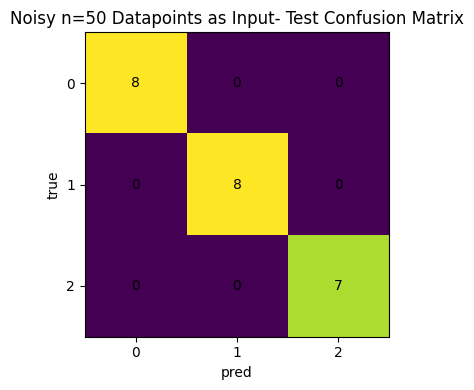

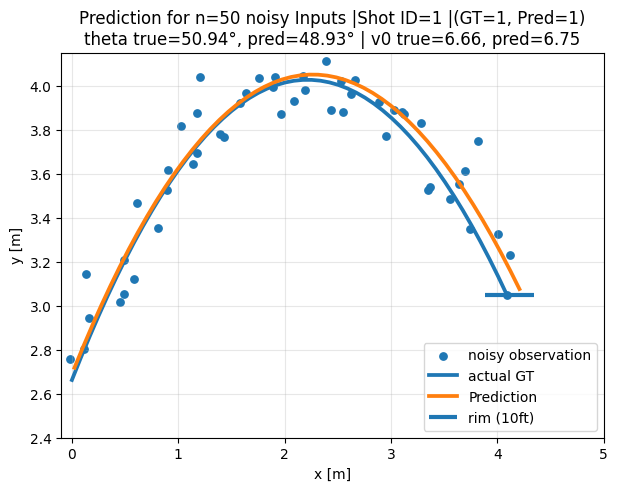

In [ ]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=50, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=50, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=50, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=50, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_50 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(
    device
)

history_noisy = train_model(
    model_noisy_50,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader_noisy,
    model_noisy_50,
    titel="Noisy n=50 Datapoints as Input- Test Confusion Matrix",
)

demo_reconstruction_noisy_vs_clean(
    model_noisy_50, test_ds_noisy, test_ds_clean, n_obs=50, idx=0
)

Epoch    1 | train 357.5027 | val 9.6704 (data 0.3817, phys 4.9421, cls 1.1391)
Epoch   10 | train 6.9728 | val 6.1047 (data 0.4447, phys 3.3350, cls 1.0976)
Epoch   20 | train 3.5007 | val 4.2230 (data 0.1954, phys 0.6565, cls 1.0969)
Epoch   30 | train 1.7575 | val 1.4436 (data 0.0708, phys 0.8799, cls 1.0979)
Epoch   40 | train 4.2825 | val 2.6422 (data 0.1206, phys 1.4922, cls 1.0945)
Epoch   50 | train 1.6993 | val 1.0727 (data 0.0734, phys 0.5398, cls 1.0626)
Epoch   60 | train 1.0912 | val 0.6904 (data 0.0524, phys 0.2004, cls 0.9292)
Epoch   70 | train 0.4529 | val 0.4031 (data 0.0302, phys 0.1073, cls 0.8757)
Epoch   80 | train 0.3978 | val 0.3565 (data 0.0287, phys 0.0303, cls 0.6659)
Epoch   90 | train 0.4580 | val 0.3139 (data 0.0225, phys 0.0824, cls 0.6447)
Epoch  100 | train 0.4811 | val 0.2730 (data 0.0189, phys 0.0586, cls 0.6668)
Epoch  110 | train 0.6832 | val 0.6166 (data 0.0292, phys 0.2034, cls 1.4407)
Early stopping.
Accuracy: 0.8260869565217391

Classification r

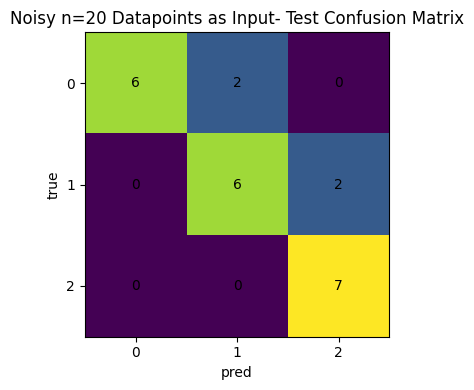

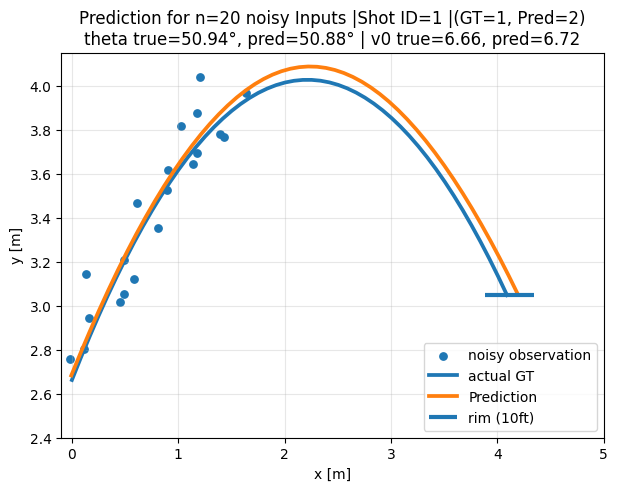

In [ ]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=20, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=20, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_20 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model_noisy_20,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader_noisy, model_noisy_20, titel ="Noisy n=20 Datapoints as Input- Test Confusion Matrix" )

demo_reconstruction_noisy_vs_clean(model_noisy_20,test_ds_noisy, test_ds_clean, n_obs=20, idx=0)

Epoch    1 | train 355.1255 | val 9.5125 (data 0.3219, phys 5.6079, cls 1.1188)
Epoch   10 | train 5.2070 | val 5.1582 (data 0.3648, phys 3.0592, cls 1.1147)
Epoch   20 | train 4.5541 | val 4.4882 (data 0.3699, phys 1.2652, cls 1.0988)
Epoch   30 | train 1.8055 | val 1.1940 (data 0.0566, phys 0.8725, cls 1.0976)
Epoch   40 | train 1.9564 | val 0.9281 (data 0.0627, phys 0.2981, cls 1.0744)
Epoch   50 | train 0.7327 | val 1.0196 (data 0.0734, phys 0.4372, cls 0.9719)
Epoch   60 | train 0.2507 | val 0.6511 (data 0.0407, phys 0.3270, cls 0.9450)
Epoch   70 | train 0.4710 | val 0.2057 (data 0.0144, phys 0.0528, cls 0.9708)
Epoch   80 | train 0.2093 | val 0.1458 (data 0.0109, phys 0.0719, cls 0.6034)
Epoch   90 | train 0.1309 | val 0.0776 (data 0.0081, phys 0.0132, cls 0.2245)
Epoch  100 | train 0.1641 | val 0.1666 (data 0.0052, phys 0.1252, cls 0.3060)
Epoch  110 | train 0.1058 | val 0.1928 (data 0.0064, phys 0.1321, cls 0.1708)
Epoch  120 | train 0.1026 | val 0.1865 (data 0.0062, phys 0.12

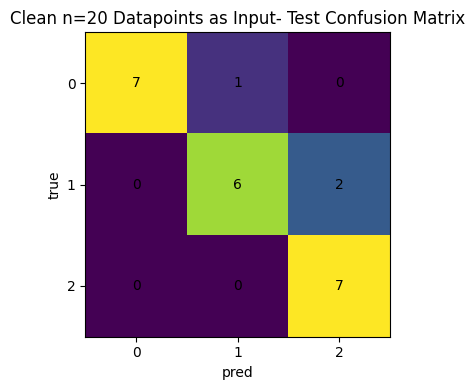

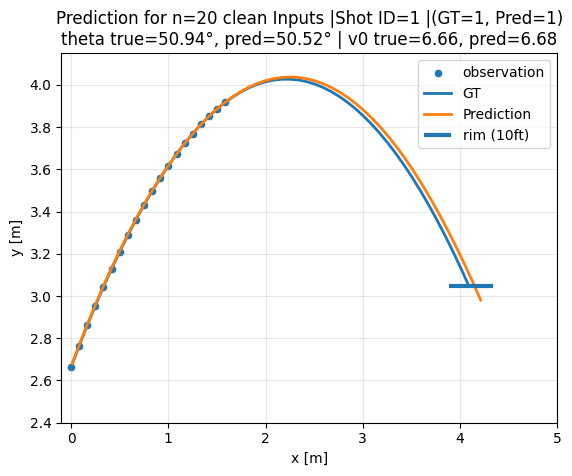

In [158]:
train_ds_clean20 = FreeThrowDataset(df, train_ids, n_obs=20, use_noisy=False)
val_ds_clean20 = FreeThrowDataset(df, val_ids, n_obs=20, use_noisy=False)
test_ds_clean20 = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=False)

train_loader20 = DataLoader(
    train_ds_clean20, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader20 = DataLoader(
    val_ds_clean20, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader20 = DataLoader(
    test_ds_clean20, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_clean_20 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_20 = train_model(
    model_clean_20,
    train_loader20,
    val_loader20,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader20, model_clean_20, titel="Clean n=20 Datapoints as Input- Test Confusion Matrix")

demo_reconstruction(
    model_clean_20, test_ds_clean20, n_obs=20, idx=0
)

Epoch    1 | train 318.5323 | val 11.1941 (data 0.2064, phys 5.9274, cls 1.1011)
Epoch   10 | train 142.8581 | val 189.1628 (data 0.3643, phys 185.2719, cls 1.0989)
Epoch   20 | train 49.4503 | val 2.6580 (data 0.1147, phys 1.6830, cls 1.1089)
Epoch   30 | train 1.7491 | val 1.4008 (data 0.0741, phys 0.6290, cls 1.1065)
Epoch   40 | train 0.9772 | val 0.9329 (data 0.0645, phys 0.4569, cls 1.0989)
Epoch   50 | train 1.9561 | val 1.2757 (data 0.0350, phys 0.9415, cls 1.1034)
Epoch   60 | train 1.4111 | val 1.3751 (data 0.0323, phys 1.0225, cls 1.0869)
Epoch   70 | train 0.7970 | val 0.4620 (data 0.0277, phys 0.1692, cls 1.0391)
Epoch   80 | train 0.5835 | val 0.6803 (data 0.0487, phys 0.1547, cls 1.0678)
Epoch   90 | train 0.9388 | val 0.4301 (data 0.0301, phys 0.1612, cls 1.0401)
Epoch  100 | train 0.4947 | val 0.3341 (data 0.0229, phys 0.0912, cls 0.8195)
Epoch  110 | train 0.4235 | val 0.3260 (data 0.0173, phys 0.0990, cls 0.9747)
Epoch  120 | train 0.3488 | val 0.3041 (data 0.0162, p

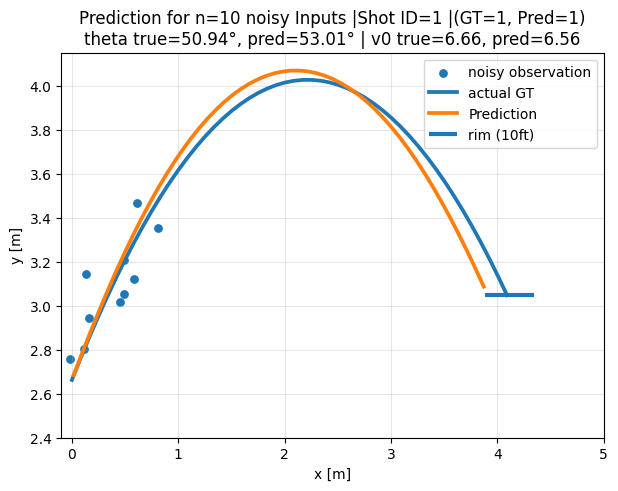

In [ ]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=10, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=10, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model_noisy_10,
    train_loader_noisy,
    val_loader_noisy,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader_noisy, model_noisy_10)

demo_reconstruction_noisy_vs_clean(
    model_noisy_10, test_ds_noisy, test_ds_clean, n_obs=10, idx=0
)

Epoch    1 | train 317.0311 | val 9.7086 (data 0.2278, phys 4.1348, cls 1.1028)
Epoch   10 | train 93.7523 | val 5.0331 (data 0.1297, phys 3.2045, cls 1.1764)
Epoch   20 | train 2.5111 | val 247.8861 (data 0.1994, phys 246.8065, cls 1.1142)
Epoch   30 | train 2.2937 | val 2.7422 (data 0.1055, phys 1.9921, cls 1.1112)
Epoch   40 | train 1.9185 | val 1.4751 (data 0.0563, phys 1.1255, cls 1.1153)
Epoch   50 | train 1.2640 | val 1.7868 (data 0.0191, phys 1.6579, cls 1.0969)
Epoch   60 | train 0.9564 | val 0.6692 (data 0.0304, phys 0.3699, cls 1.1253)
Epoch   70 | train 0.2978 | val 0.4829 (data 0.0131, phys 0.3688, cls 1.0082)
Epoch   80 | train 0.3551 | val 0.4647 (data 0.0192, phys 0.2983, cls 1.0236)
Epoch   90 | train 0.7045 | val 0.3668 (data 0.0215, phys 0.1747, cls 1.0186)
Epoch  100 | train 0.3988 | val 0.1514 (data 0.0124, phys 0.0592, cls 0.9982)
Epoch  110 | train 0.1895 | val 0.1208 (data 0.0097, phys 0.0269, cls 0.9656)
Epoch  120 | train 0.1732 | val 0.2278 (data 0.0066, phys

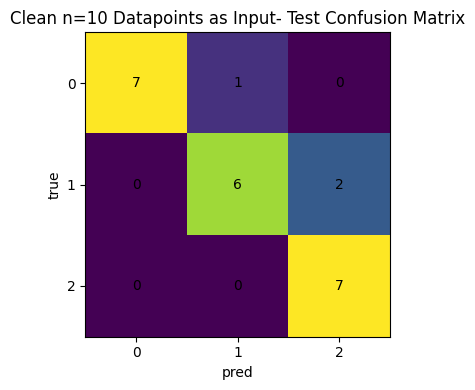

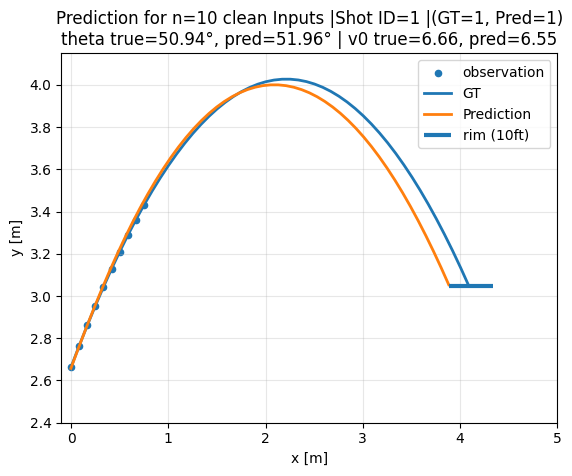

In [159]:
train_ds_clean_10 = FreeThrowDataset(df, train_ids, n_obs=10, use_noisy=False)
val_ds_clean_10 = FreeThrowDataset(df, val_ids, n_obs=10, use_noisy=False)
test_ds_clean_10 = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=False)

train_loader10 = DataLoader(train_ds_clean_10, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader10 = DataLoader(val_ds_clean_10, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader10 = DataLoader(test_ds_clean_10, batch_size=64, shuffle=False, collate_fn=collate_fn)
model_clean_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

model_clean_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_10 = train_model(
    model_clean_10,
    train_loader10,
    val_loader10,
    epochs=200,
    lr=2e-3,
    patience=25,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(test_loader10, model_clean_10, titel="Clean n=10 Datapoints as Input- Test Confusion Matrix")

demo_reconstruction(model_clean_10, test_ds_clean_10, n_obs=10, idx=0)